#  Amazon Sales Data Analysis

##  Problem Statement
The objective of this project is to perform Exploratory Data Analysis (EDA) on Amazon sales data to identify sales trends, key revenue drivers, and customer behavior.

This analysis aims to answer:
- Which products and categories generate the most revenue?
- How do sales vary over time?
- Which locations contribute the most to sales?
- What patterns can help improve business decisions?

##  Objective
To derive actionable business insights that help in improving sales strategy, marketing, and inventory planning.

In [49]:
# importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
# Data loading
df=pd.read_csv("amazon_sales_data 2025.csv")
df.head()

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
0,ORD0001,14-03-25,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled
1,ORD0002,20-03-25,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending
2,ORD0003,15-02-25,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled
3,ORD0004,19-02-25,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending
4,ORD0005,10-03-25,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending


In [51]:
df.shape

(250, 11)

In [52]:
df.columns

Index(['Order ID', 'Date', 'Product', 'Category', 'Price', 'Quantity',
       'Total Sales', 'Customer Name', 'Customer Location', 'Payment Method',
       'Status'],
      dtype='object')

In [54]:
# Data cleaning
df["Date"]=pd.to_datetime(df["Date"])

In [55]:
#checking missing values
df.isnull().sum()

Order ID             0
Date                 0
Product              0
Category             0
Price                0
Quantity             0
Total Sales          0
Customer Name        0
Customer Location    0
Payment Method       0
Status               0
dtype: int64

In [56]:
df.duplicated().sum()

0

In [57]:
# feature engeneering 
df['Month']=df['Date'].dt.month
df['Year']=df['Date'].dt.year
df['Day']=df['Date'].dt.day

In [58]:
df.columns=df.columns.str.strip()

In [59]:
df['Date']

0     2025-03-14
1     2025-03-20
2     2025-02-15
3     2025-02-19
4     2025-10-03
         ...    
245   2025-03-17
246   2025-03-30
247   2025-05-03
248   2025-08-03
249   2025-02-19
Name: Date, Length: 250, dtype: datetime64[ns]

In [60]:
df.head()

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status,Month,Year,Day
0,ORD0001,2025-03-14,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled,3,2025,14
1,ORD0002,2025-03-20,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending,3,2025,20
2,ORD0003,2025-02-15,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled,2,2025,15
3,ORD0004,2025-02-19,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending,2,2025,19
4,ORD0005,2025-10-03,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending,10,2025,3


In [62]:
df.groupby("Month")['Total Sales'].sum()

Month
1      2120
2     77610
3     78295
4     12715
5      8300
6     21120
7     11180
8      4765
9      3750
10    14930
11     4790
12     4270
Name: Total Sales, dtype: int64

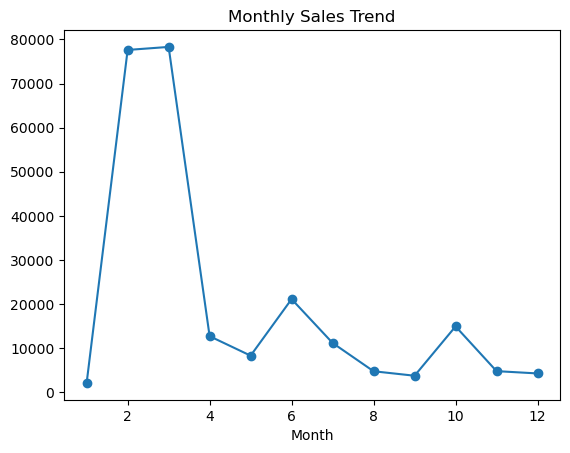

In [63]:
# Analysis
df.groupby('Month')['Total Sales'].sum().plot(marker='o')
plt.title("Monthly Sales Trend")
plt.show()

In [64]:
df[['Date','Month','Year','Day']].head()

,Date,Month,Year,Day
0,2025-03-14,3,2025,14
1,2025-03-20,3,2025,20
2,2025-02-15,2,2025,15
3,2025-02-19,2,2025,19
4,2025-10-03,10,2025,3


### Buisiness insights 

In [65]:
-- sales pack significantly during february and march strong seosonal demand
--There is a sharp decline after march suggesting post season slowdown
-- a secondary increase is observed around june possibly due tp mid-year
-- slight recovary is seen in october indicating potential festive or promotional impact 

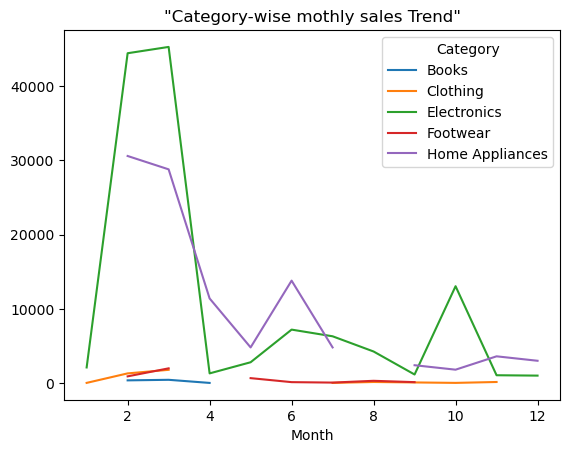

In [39]:
df.groupby(['Month','Category'])['Total Sales'].sum().unstack().plot()
plt.title('"Category-wise mothly sales Trend"')
plt.show()

### category-wise insights


In [ ]:
-- Electronics category drives peak sales during Feb-March
-- Footwear shows consistent but lower sales 
-- some categories have seosonal dependency

In [42]:
df.groupby('Product')['Total Sales'].sum().sort_values(ascending=False).head(10)

Product
Refrigerator       78000
Laptop             58400
Smartphone         48500
Washing Machine    27000
Smartwatch         15750
Headphones          7300
Running Shoes       4320
Jeans               2480
T-Shirt             1060
Book                1035
Name: Total Sales, dtype: int64

In [44]:
df.groupby('Customer Location')['Total Sales'].sum().sort_values(ascending=False).head(10)

Customer Location
Miami            31700
Denver           29785
Houston          28390
Dallas           27145
Seattle          26890
Boston           26170
Chicago          20810
New York         18940
Los Angeles      17820
San Francisco    16195
Name: Total Sales, dtype: int64

### Customer Location insights


In [ ]:
-- Miami generates the highest revenue,making it the top performing location 
-- Denver and Houston also contribute significantly total sales 
-- sales are relatively well distributed across multiple cities
-- cities like San Francisco and Los Angeles show comparitively low sales 
-- this indicates region variation in customer demand 

## Conclusion

The analysis highlights that Electronics is the top-performing category, with peak sales occurring during February and March. Revenue is concentrated among a few high-value products, and certain locations contribute more significantly to overall sales. These insights can help businesses improve sales strategies and decision-making.